In [20]:
import pandas as pd 

In [21]:
df = pd.read_csv("../../data/Clean_BNPParibas_Data.csv")

X = df.drop(columns=["contract_type", "customer_id"])
y = df["contract_type"]

In [22]:
print(y.value_counts(normalize=True) * 100)

contract_type
Month-to-Month    59.165752
One Year          27.442371
Two Year          13.391877
Name: proportion, dtype: float64


In [23]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'tenure_months', 'monthly_charges', 'total_charges', 'support_tickets', 'churn']

Categorical features:
['internet_service', 'payment_method']


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression()
        )
    ]
)

In [28]:
logistic_model.fit(X_train,y_train)
logistic_predictions = (logistic_model.predict(X_test))
logistic_probabilities = logistic_model.predict_proba(X_test)

In [29]:
from sklearn.tree import DecisionTreeClassifier

tree_classifier = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

In [30]:
tree_classifier.fit(X_train,y_train)
tree_predictions = (tree_classifier.predict(X_test))
tree_probabilities = tree_classifier.predict_proba(X_test)

In [31]:
from sklearn.ensemble import RandomForestClassifier

forest_classifier = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

In [32]:
forest_classifier.fit(X_train,y_train)
forest_predictions = (forest_classifier.predict(X_test))
forest_probabilities = forest_classifier.predict_proba(X_test)

In [33]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

tree_accuracy = accuracy_score(
    y_test,
    tree_predictions
)

forest_accuracy = accuracy_score(
    y_test,
    forest_predictions
)

In [34]:
accuracy_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ]
})

display(accuracy_comparison)

,Model,Accuracy
0,Logistic Regression,0.590164
1,Decision Tree,0.442623
2,Random Forest,0.562842


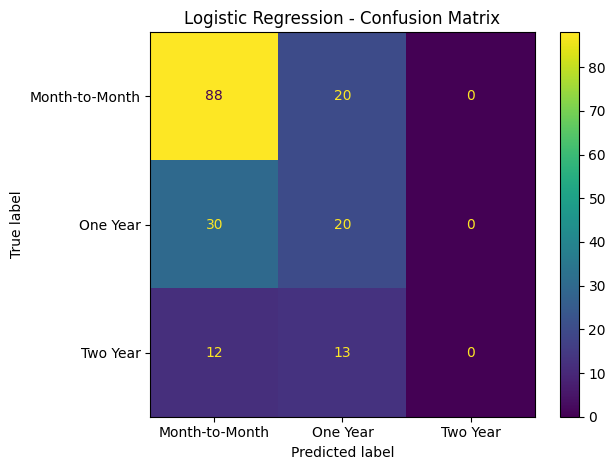

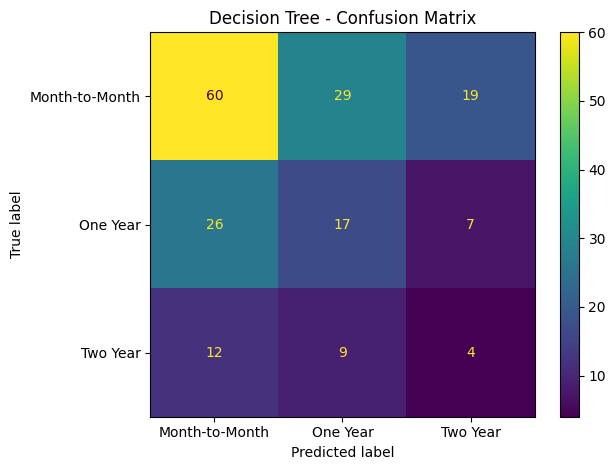

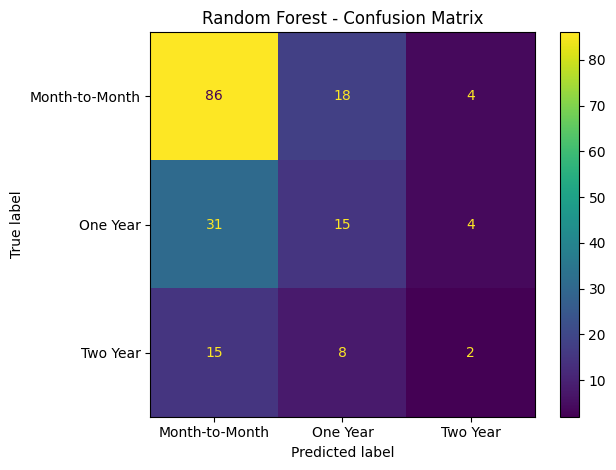

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_predictions
)

plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_predictions
)

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

In [36]:
from sklearn.preprocessing import label_binarize

classes = sorted(y_test.unique())

y_test_binary = label_binarize(
    y_test,
    classes=classes
)

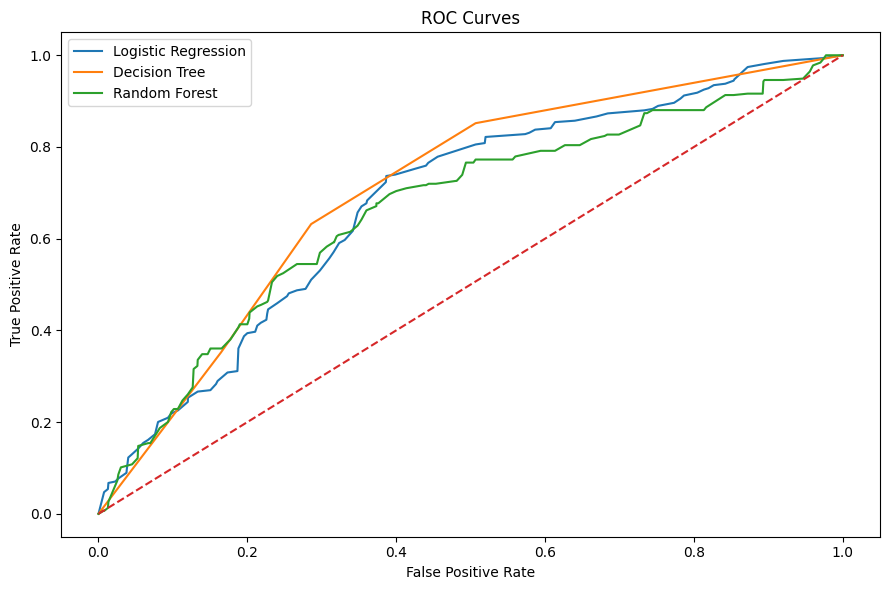

In [37]:
from sklearn.metrics import roc_curve

models = {
    "Logistic Regression": logistic_probabilities,
    "Decision Tree": tree_probabilities,
    "Random Forest": forest_probabilities
}

plt.figure(figsize=(9, 6))

for model_name, probabilities in models.items():

    fpr = {}
    tpr = {}

    for i in range(len(classes)):

        fpr[i], tpr[i], _ = roc_curve(
            y_test_binary[:, i],
            probabilities[:, i]
        )

    # Macro-average ROC
    all_fpr = sorted(
        set(
            value
            for i in fpr
            for value in fpr[i]
        )
    )

    mean_tpr = []

    for x in all_fpr:

        values = [
            tpr[i][
                next(
                    j for j, value
                    in enumerate(fpr[i])
                    if value >= x
                )
            ]
            for i in range(len(classes))
            if x <= fpr[i][-1]
        ]

        mean_tpr.append(
            sum(values) / len(values)
        )

    plt.plot(
        all_fpr,
        mean_tpr,
        label=model_name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()

plt.tight_layout()
plt.show()

In [40]:
feature_names = (
    preprocessor
    .fit(X_train)
    .get_feature_names_out()
)

,Feature,Importance
0,num__age,0.191171
3,num__total_charges,0.177381
2,num__monthly_charges,0.168015
1,num__tenure_months,0.145492
5,num__churn,0.128549
4,num__support_tickets,0.085898
8,cat__payment_method_Bank Transfer,0.025225
6,cat__internet_service_DSL,0.022111
10,cat__payment_method_Credit Card,0.021408
7,cat__internet_service_Fiber,0.019896


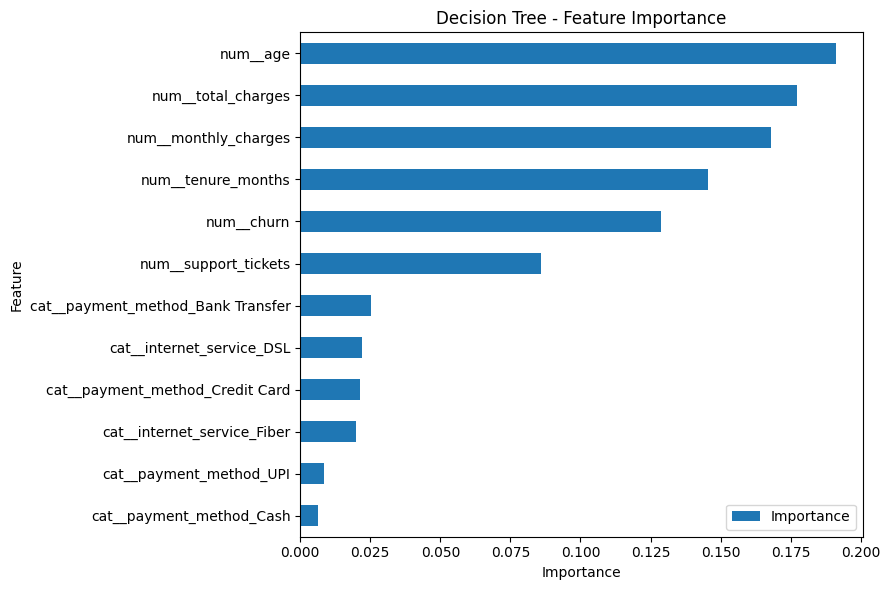

In [42]:

tree_importance = tree_classifier[
    "classifier"
].feature_importances_

tree_features = pd.DataFrame({
    "Feature": feature_names,
    "Importance": tree_importance
})

tree_features = tree_features.sort_values(
    "Importance",
    ascending=False
)

display(
    tree_features.head(15)
)

tree_features.head(15).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(9, 6)
)

plt.title("Decision Tree - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [43]:
logistic_coefficients = logistic_model[
    "classifier"
].coef_

logistic_importance = (
    abs(logistic_coefficients)
    .mean(axis=0)
)

logistic_features = pd.DataFrame({
    "Feature": feature_names,
    "Importance": logistic_importance
})

logistic_features = logistic_features.sort_values(
    "Importance",
    ascending=False
)

display(
    logistic_features.head(15)
)

,Feature,Importance
5,num__churn,0.488396
3,num__total_charges,0.147938
11,cat__payment_method_UPI,0.147307
8,cat__payment_method_Bank Transfer,0.135559
9,cat__payment_method_Cash,0.125894
1,num__tenure_months,0.113967
2,num__monthly_charges,0.105613
6,cat__internet_service_DSL,0.100518
7,cat__internet_service_Fiber,0.099526
4,num__support_tickets,0.086268


,Feature,Importance
2,num__monthly_charges,0.183850
3,num__total_charges,0.174870
1,num__tenure_months,0.161021
0,num__age,0.158033
5,num__churn,0.123811
4,num__support_tickets,0.082544
10,cat__payment_method_Credit Card,0.023614
11,cat__payment_method_UPI,0.022320
9,cat__payment_method_Cash,0.019442
8,cat__payment_method_Bank Transfer,0.018123


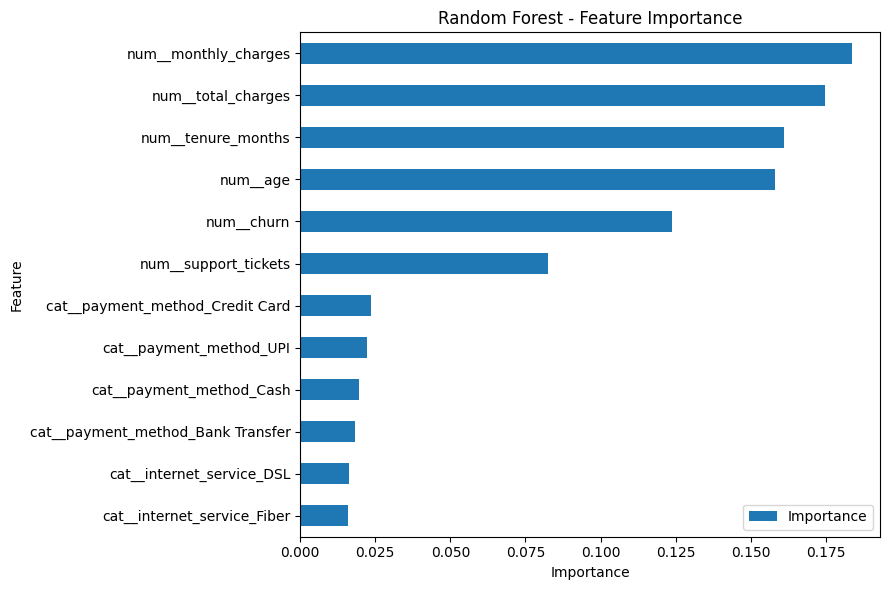

In [45]:
forest_importance = forest_classifier[
    "classifier"
].feature_importances_

forest_features = pd.DataFrame({
    "Feature": feature_names,
    "Importance": forest_importance
})

forest_features = forest_features.sort_values(
    "Importance",
    ascending=False
)

display(
    forest_features.head(15)
)

forest_features.head(15).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(9, 6)
)

plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()